<div style="display: flex; align-items: center;">
    <h1>Training a neural partitioning module</h1>
    <img src="https://raw.githubusercontent.com/WUR-AI/diffWOFOST/refs/heads/main/docs/logo/diffwofost.png" width="150" style="margin-left: 20px;">
</div>

This notebook is a worked example of how to replace one process-based WOFOST module with a neural network while leaving the rest of the model unchanged.

The example uses the Fontane 2020 setup from the pcse-notebook <code>11 Optimizing partitioning in a PCSE model.ipynb</code>. We keep the standard <code>Wofost72</code> crop model, but swap only its internal <code>partitioning</code> component for a trainable neural module that predicts <code>FR</code>, <code>FL</code>, <code>FS</code>, and <code>FO</code> from crop development stage <code>DVS</code>.

By the end of the notebook, the replacement pattern should be clear:

1. keep the original simulation workflow and data inputs
2. provide a neural module that matches the expected component interface
3. inject that module through <code>component_overrides</code>
4. train only the replacement module and inspect how the simulation changes

## 1. Software requirements

Install the latest version of <code>diffwofost</code>. This notebook also uses <code>pcse</code>, <code>pandas</code>, <code>openpyxl</code>, and <code>matplotlib</code>.

To keep the example self-contained, the notebook downloads the required external inputs automatically:

1. the Fontane 2020 weather workbook (FIX! <code>fix_data_nb_11</code>)
2. the <code>pcse/conf/Wofost72_PP.conf</code> file from <code>ajwdewit/pcse</code>
3. the Fontane 2020 <code>agro</code>, <code>obs</code>, and <code>crop</code> assets from <code>ajwdewit/pcse_notebooks/data</code>

In [1]:
# install required packages when needed
%pip install diffwofost matplotlib pandas openpyxl pcse

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy
import warnings
from pathlib import Path
from urllib.error import HTTPError, URLError
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import pandas as pd
import torch
from pcse.base import ParameterProvider
from pcse.input import (
    ExcelWeatherDataProvider,
    YAMLAgroManagementReader,
    YAMLCropDataProvider,
    WOFOST72SiteDataProvider,
    )
from pcse.util import DummySoilDataProvider

from diffwofost.ml_models.crop.partitioning import DVS_Partitioning_NN, PartitioningMLP, PartitioningNN
from diffwofost.physical_models.config import ComputeConfig, Configuration
from diffwofost.physical_models.crop.wofost72 import Wofost72
from diffwofost.physical_models.engine import Engine
from diffwofost.physical_models.soil.classic_waterbalance import WaterbalancePP

warnings.filterwarnings("ignore", message="To copy construct from a tensor.*")
ComputeConfig.set_device("cpu")
ComputeConfig.set_dtype(torch.float64)

## 2. Load the Fontane 2020 field dataset

The weather workbook is loaded directly with <code>ExcelWeatherDataProvider</code>, while the Fontane 2020 agromanagement, observation, and crop parameter files are downloaded from <code>pcse_notebooks</code> into the same local directory structure expected by the original notebook.

The hybrid training target in this notebook is the observed field series for <code>WLV</code>, <code>TWST</code>, <code>TWSO</code>, and <code>LAI</code>.


In [3]:
location = "le"
variety = "C2"
year = 2020

notebook_dir = Path.cwd()
data_dir = notebook_dir / "data"
weather_url = (
    "https://raw.githubusercontent.com/WUR-AI/diffWOFOST/"
    f"fix_data_nb_11/docs/notebooks/data/weatherfile_{location}_{year}.xlsx"
    )
conf_url = "https://raw.githubusercontent.com/ajwdewit/pcse/master/pcse/conf/Wofost72_PP.conf"
pcse_notebooks_data_url = "https://raw.githubusercontent.com/ajwdewit/pcse_notebooks/master/data"

agro_path = data_dir / "agro" / f"AGMT_{variety}_{year}.agro"
obs_path = data_dir / "obs" / f"OBSV_{variety}_{year}.xlsx"
crop_path = data_dir / "crop"


def download_remote_file(url: str, destination_dir: Path, destination_name: str) -> Path:
    destination_dir.mkdir(parents=True, exist_ok=True)
    destination_path = destination_dir / destination_name
    if not destination_path.exists():
        print(f"Downloading {destination_name} from {url}")
        try:
            urlretrieve(url, destination_path)
        except (HTTPError, URLError) as exc:
            raise RuntimeError(
                f"Failed to download {destination_name} from GitHub. "
                "Check your internet connection or download the file manually."
            ) from exc
    return destination_path


def download_many_files(base_url: str, destination_dir: Path, filenames: list[str]) -> list[Path]:
    return [
        download_remote_file(f"{base_url}/{filename}", destination_dir, filename)
        for filename in filenames
    ]


weather_path = download_remote_file(
    weather_url,
    data_dir / "meteo",
    f"weatherfile_{location}_{year}.xlsx",
    )
conf_path = download_remote_file(conf_url, data_dir / "conf", "Wofost72_PP.conf")
download_many_files(
    f"{pcse_notebooks_data_url}/agro",
    data_dir / "agro",
    [f"AGMT_{variety}_{year}.agro"],
    )
download_many_files(
    f"{pcse_notebooks_data_url}/obs",
    data_dir / "obs",
    [f"OBSV_{variety}_{year}.xlsx"],
    )
crop_files = download_many_files(
    f"{pcse_notebooks_data_url}/crop",
    crop_path,
    ["crops.yaml", "potato.yaml"],
    )

print(f"Using weather file: {weather_path.name}")
print(f"Using configuration file: {conf_path.name}")
print(f"Using agromanagement file: {agro_path.name}")
print(f"Using observation file: {obs_path.name}")
print("Using crop parameter files:", ", ".join(path.name for path in crop_files))

Using weather file: weatherfile_le_2020.xlsx
Using configuration file: Wofost72_PP.conf
Using agromanagement file: AGMT_C2_2020.agro
Using observation file: OBSV_C2_2020.xlsx
Using crop parameter files: crops.yaml, potato.yaml


In [4]:
weather_data_provider = ExcelWeatherDataProvider(weather_path)
crop_data_provider = YAMLCropDataProvider(fpath=crop_path, force_reload=True)
soil_data_provider = DummySoilDataProvider()
site_data_provider = WOFOST72SiteDataProvider(WAV=10)
parameter_provider = ParameterProvider(
    cropdata=crop_data_provider,
    soildata=soil_data_provider,
    sitedata=site_data_provider,
    )
agro_management_inputs = YAMLAgroManagementReader(agro_path)

observations = pd.read_excel(obs_path)
observations = observations.rename(columns={"LeafDM": "WLV", "StemDM": "TWST", "TuberDM": "TWSO"})
observations.index = pd.to_datetime(observations["DateMeas"])
observations = observations.sort_index()

display(observations[["DateMeas", "WLV", "TWST", "TWSO", "LAI"]].head())


Using this class from pcse.util is deprecated, use pcse.input.DummySoilDataProvider


,DateMeas,WLV,TWST,TWSO,LAI
DateMeas,,,,,
2020-06-08,2020-06-08,422.503624,96.182448,0.000000,0.783577
2020-06-21,2020-06-21,1469.952103,466.980393,1139.640672,3.210881
2020-07-13,2020-07-13,1836.000000,993.000000,6107.334389,4.428320
2020-08-03,2020-08-03,1649.952103,1017.609318,9657.705361,4.428320
2020-09-07,2020-09-07,981.522075,875.226102,NaN,1.982688


## 3. Load the neural replacement candidates

To replace a PCSE/WOFOST module with a neural network, we need two pieces:

1. a trainable PyTorch model
2. a PCSE-compatible wrapper that exposes that model in the place where the crop model expects the original component

The package already provides both in <code>diffwofost.ml_models.crop.partitioning</code>. The wrapper class <code>DVS_Partitioning_NN</code> makes the neural model behave like the original partitioning block from the rest of WOFOST's point of view.

In this notebook we compare two candidate neural replacements:

1. <code>PartitioningMLP</code>: a compact one-hidden-layer baseline
2. <code>PartitioningNN</code>: a more structured stage-aware network

Both models still enforce physically valid outputs: <code>FR</code> is mapped through a sigmoid, while <code>FL</code>, <code>FS</code>, and <code>FO</code> are mapped through a softmax so they sum to 1.

In [5]:
partition_mlp = PartitioningMLP(hidden_size=32)
partition_nn = PartitioningNN(hidden_size=32)

print(partition_mlp)
print()
print(partition_nn)

PartitioningMLP(
  (network): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): SiLU()
    (2): Linear(in_features=32, out_features=4, bias=True)
  )
)

PartitioningNN(
  (trunk): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): SiLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): SiLU()
  )
  (fr_head): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): SiLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
  )
  (shoot_head): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): SiLU()
    (2): Linear(in_features=16, out_features=3, bias=True)
  )
)


## 4. Replace the default partitioning module

This section is the core of the notebook. The important point is that the ML module is not wired into the engine manually. It is injected through the model configuration.

That means there are two equivalent ways to set up the replacement:

1. preferred: define the replacement outside the notebook in the config you want to run
2. shown here: modify the configuration object in Python so the injection is visible step by step

In both cases, almost everything else stays the same:

1. the weather, crop, soil, and agromanagement inputs stay the same
2. the engine setup and run loop stay the same
3. only one crop submodule is replaced

We start from the upstream <code>Wofost72_PP.conf</code> file, rebuild the runtime configuration with the diffWOFOST crop and soil classes, and then inject a replacement only for <code>partitioning</code>.

For real model setups, it is usually better to express that choice directly in the configuration you store and reuse, rather than editing the configuration object interactively inside a notebook. The notebook approach is useful here because it makes the injection mechanism explicit.

The important configuration choices are:

1. <code>Wofost72_PP.conf</code>: keep the standard potential-production WOFOST72 setup from PCSE
2. <code>CROP=Wofost72</code>: switch the crop implementation to the diffWOFOST-compatible class
3. <code>SOIL=WaterbalancePP</code>: keep the potential-production soil water balance
4. <code>OUTPUT_VARS=[...]</code>: request only the variables used in this notebook, including observation-facing biomass outputs and internal partitioning factors
5. <code>CROP_KWARGS["component_overrides"]["partitioning"]</code>: inject the replacement module through config (link to new ML documentation)

In [6]:
output_vars = ["DVS", "LAI", "TAGP", "WLV", "TWST", "TWSO", "FR", "FL", "FS", "FO"]

base_pcse_config = Configuration.from_pcse_config_file(conf_path)

reference_config = Configuration(
    CROP=Wofost72,
    SOIL=WaterbalancePP,
    AGROMANAGEMENT=base_pcse_config.AGROMANAGEMENT,
    OUTPUT_VARS=output_vars.copy(),
    SUMMARY_OUTPUT_VARS=list(base_pcse_config.SUMMARY_OUTPUT_VARS),
    TERMINAL_OUTPUT_VARS=list(base_pcse_config.TERMINAL_OUTPUT_VARS),
    OUTPUT_INTERVAL=base_pcse_config.OUTPUT_INTERVAL,
    OUTPUT_INTERVAL_DAYS=base_pcse_config.OUTPUT_INTERVAL_DAYS,
    OUTPUT_WEEKDAY=base_pcse_config.OUTPUT_WEEKDAY,
    model_config_file=base_pcse_config.model_config_file,
    description=base_pcse_config.description,
    )

hybrid_config = copy.deepcopy(reference_config)
hybrid_config.CROP_KWARGS["component_overrides"] = {
    "partitioning": {
        "class": DVS_Partitioning_NN,
        "model": partition_nn,
    }
}

print("Base configuration loaded from:", reference_config.model_config_file)
print("Stored outputs:", ", ".join(reference_config.OUTPUT_VARS))

Base configuration loaded from: /home/simone/Dropbox/eScience_projects/diffWOFOST/docs/notebooks/data/conf/Wofost72_PP.conf
Stored outputs: DVS, LAI, TAGP, WLV, TWST, TWSO, FR, FL, FS, FO


The configuration cell above creates two nearly identical model setups:

1. <code>reference_config</code>: the default WOFOST72 partitioning module
2. <code>hybrid_config</code>: the same setup, but with an injected override for <code>partitioning</code>

The essential idea is that the ML module enters the model through configuration, not through special engine logic. The explicit injection hook used here is:

```python
hybrid_config.CROP_KWARGS["component_overrides"] = {
    "partitioning": {
        "class": DVS_Partitioning_NN,
        "model": partition_nn,
    }
}
```

That is the pattern to reuse when you want to replace another compatible module: keep the overall model configuration, override one named component, and pass the replacement class together with its model object or constructor arguments.

The helper functions below keep the simulation path identical for the default and hybrid cases, so any difference later comes from the replaced module rather than from the rest of the workflow.

They also align the simulation output with the observed field dates so the optimization loss is evaluated only where measurements exist.

### 4.1 Helper functions for running model variants

The first helper block keeps the simulation interface compact. Each function runs the same WOFOST workflow, but with a different partitioning choice: the default module or a neural replacement.

This separation matters for the rest of the notebook: later sections can focus on training and comparison without repeating engine setup code.

In [7]:
variable_mapping = {
    "WLV": "WLV",
    "TWST": "TWST",
    "TWSO": "TWSO",
    "LAI": "LAI",
}
variable_weights = {name: 1.0 for name in variable_mapping}


def run_engine(config, parameter_provider_override=None, copy_parameter_provider=True):
    model_parameter_provider = (
        parameter_provider if parameter_provider_override is None else parameter_provider_override
    )
    if copy_parameter_provider:
        model_parameter_provider = copy.deepcopy(model_parameter_provider)

    engine = Engine(config=config)
    engine.setup(
        model_parameter_provider,
        weather_data_provider,
        agro_management_inputs,
    )
    engine.run_till_terminate()
    return engine.get_output()


def results_to_tensors(results):
    tensor_results = {"day": [pd.Timestamp(item["day"]) for item in results]}
    for varname in output_vars:
        tensor_results[varname] = torch.stack(
            [
                torch.as_tensor(
                    item[varname],
                    dtype=ComputeConfig.get_dtype(),
                    device=ComputeConfig.get_device(),
                )
                for item in results
            ]
        )
    return tensor_results


def run_reference_wofost72():
    return results_to_tensors(run_engine(reference_config))


def run_hybrid_wofost72(partition_model):
    hybrid_config.CROP_KWARGS["component_overrides"]["partitioning"]["model"] = partition_model
    return results_to_tensors(run_engine(hybrid_config))


### 4.2 Match observations to simulation days

The field observations are not available for every simulated day. This helper aligns the measured timestamps with the model output and returns the tensor indices that will later be used in the loss.

That way, training compares model output and observations only on dates where measurements actually exist.

In [8]:
def build_observation_targets(simulation_days, df_obs):
    day_lookup = {pd.Timestamp(day).normalize(): idx for idx, day in enumerate(simulation_days)}
    matched_timestamps = [
        timestamp
        for timestamp in df_obs.index
        if pd.Timestamp(timestamp).normalize() in day_lookup
    ]
    if not matched_timestamps:
        raise RuntimeError("No observation dates matched the simulation output.")

    matched_observations = df_obs.loc[matched_timestamps].copy()
    matched_positions = [day_lookup[pd.Timestamp(timestamp).normalize()] for timestamp in matched_timestamps]
    observation_indices = torch.tensor(
        matched_positions,
        dtype=torch.long,
        device=ComputeConfig.get_device(),
    )
    observation_targets = {
        obs_name: torch.tensor(
            matched_observations[obs_name].to_numpy(),
            dtype=ComputeConfig.get_dtype(),
            device=ComputeConfig.get_device(),
        )
        for obs_name in variable_mapping
    }
    return matched_observations, observation_indices, observation_targets

### 4.3 Define the loss and diagnostics

The main training objective is a normalized multi-output RMSE over the observed biomass and LAI variables. We also keep a separate LAI mean absolute error as an easier-to-read diagnostic.

In [9]:
def compute_observation_loss(results):
    total_loss = torch.tensor(0.0, dtype=ComputeConfig.get_dtype(), device=ComputeConfig.get_device())
    diagnostics = {}
    for obs_name, model_name in variable_mapping.items():
        predicted = results[model_name].index_select(0, observation_indices)
        target = observation_targets[obs_name]
        valid_mask = torch.isfinite(target)
        if not torch.any(valid_mask):
            raise RuntimeError(f"No finite observations are available for {obs_name}.")

        predicted = predicted[valid_mask]
        target = target[valid_mask]
        scale = torch.mean(target).clamp_min(1e-6)
        rmse = torch.sqrt(torch.mean(((predicted - target) / scale) ** 2))
        total_loss = total_loss + variable_weights[obs_name] * rmse
        diagnostics[obs_name] = rmse.detach().cpu().item()
    return total_loss, diagnostics


def compute_lai_mae(results):
    predicted_lai = results["LAI"].index_select(0, observation_indices)
    target_lai = observation_targets["LAI"]
    valid_mask = torch.isfinite(target_lai)
    if not torch.any(valid_mask):
        raise RuntimeError("No finite LAI observations are available.")
    return torch.mean(torch.abs(predicted_lai[valid_mask] - target_lai[valid_mask]))


def tensors_to_frame(results):
    frame = pd.DataFrame(index=pd.DatetimeIndex(results["day"]))
    for varname in output_vars:
        frame[varname] = results[varname].detach().cpu().numpy()
    return frame

Before training, we compare the default WOFOST72 run and both untrained neural replacements against the observed field measurements: 

In [10]:
reference_results = run_reference_wofost72()
matched_observations, observation_indices, observation_targets = build_observation_targets(
    reference_results["day"],
    observations,
    )

reference_loss, reference_metrics = compute_observation_loss(reference_results)
initial_runs = {
    "PartitioningNN": run_hybrid_wofost72(partition_nn),
    "PartitioningMLP": run_hybrid_wofost72(partition_mlp),
}

print(f"Matched observation dates: {len(matched_observations)}")
print(f"Default WOFOST72 observation loss: {reference_loss.detach().item():.4f}")
for metric_name, metric_value in reference_metrics.items():
    print(f"Default {metric_name} normalized RMSE: {metric_value:.4f}")

for model_name, model_results in initial_runs.items():
    initial_loss, initial_metrics = compute_observation_loss(model_results)
    print(f"\n{model_name} initial observation loss: {initial_loss.detach().item():.4f}")
    print(f"{model_name} initial LAI MAE: {compute_lai_mae(model_results).detach().item():.4f}")
    for metric_name, metric_value in initial_metrics.items():
        print(f"{model_name} {metric_name} normalized RMSE: {metric_value:.4f}")

Matched observation dates: 6
Default WOFOST72 observation loss: 2.0337
Default WLV normalized RMSE: 0.4057
Default TWST normalized RMSE: 0.9127
Default TWSO normalized RMSE: 0.3896
Default LAI normalized RMSE: 0.3257

PartitioningNN initial observation loss: 3.4160
PartitioningNN initial LAI MAE: 2.0333
PartitioningNN WLV normalized RMSE: 0.7971
PartitioningNN TWST normalized RMSE: 0.4966
PartitioningNN TWSO normalized RMSE: 1.2663
PartitioningNN LAI normalized RMSE: 0.8559

PartitioningMLP initial observation loss: 3.3861
PartitioningMLP initial LAI MAE: 1.9595
PartitioningMLP WLV normalized RMSE: 0.7869
PartitioningMLP TWST normalized RMSE: 0.5198
PartitioningMLP TWSO normalized RMSE: 1.2394
PartitioningMLP LAI normalized RMSE: 0.8400


## 5. Optimize the replacement module

At this point the module replacement is already complete. We now discuss how to optimize the ML modules.

Each training step runs the full hybrid crop model, samples the simulated trajectories at the actual observation dates, and backpropagates through the neural partitioning block only. The rest of the model remains fixed.

Because the simulation helper is model-agnostic, we can train <code>PartitioningNN</code> and <code>PartitioningMLP</code> with exactly the same observation loss and compare the fitted trajectories afterward.

### 5.1 Define the trainable replacement variants

This block defines the two neural replacement modules we will optimize.

Keeping these definitions separate from the training loop makes it clearer which part specifies the model family and which part handles optimization.

In [11]:
training_config = {
    "lr": 0.02,
    "max_steps": 40,
    "patience": 8,
    "min_delta": 5e-4,
}


torch.manual_seed(7)
models_to_train = {
    "PartitioningNN": {
        "model": PartitioningNN(hidden_size=32).to(
            device=ComputeConfig.get_device(),
            dtype=ComputeConfig.get_dtype(),
        ),
        "runner": run_hybrid_wofost72,
    },
    "PartitioningMLP": {
        "model": PartitioningMLP(hidden_size=32).to(
            device=ComputeConfig.get_device(),
            dtype=ComputeConfig.get_dtype(),
        ),
        "runner": run_hybrid_wofost72,
    },
}

### 5.2 Training loop and reporting

The next block is the generic optimization routine. It only needs a model and a runner function, so both neural replacements are trained in exactly the same way.

That keeps the comparison fair, because both variants use the same loss, early-stopping logic, and summary reporting.

In [12]:
def train_model_variant(
    model,
    model_name,
    runner,
    lr=0.02,
    max_steps=40,
    patience=8,
    min_delta=5e-4,
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_loss = float("inf")
    best_step = -1
    best_state = copy.deepcopy(model.state_dict())
    loss_history = []

    for step in range(max_steps):
        optimizer.zero_grad()
        predictions = runner(model)
        loss, diagnostics = compute_observation_loss(predictions)

        loss_value = loss.detach().cpu().item()
        loss_history.append(loss_value)

        if loss_value < best_loss - min_delta:
            best_loss = loss_value
            best_step = step
            best_state = copy.deepcopy(model.state_dict())

        if step % 10 == 0 or step == max_steps - 1:
            print(
                f"{model_name} | Step {step:03d} | Total loss = {loss_value:.4f} "
                f"| WLV = {diagnostics['WLV']:.4f} "
                f"| TWST = {diagnostics['TWST']:.4f} "
                f"| TWSO = {diagnostics['TWSO']:.4f} "
                f"| LAI = {diagnostics['LAI']:.4f}"
            )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        if step - best_step >= patience:
            print(f"{model_name} | Early stopping at step {step:03d}")
            break

    model.load_state_dict(best_state)
    trained_results = runner(model)
    final_loss, final_metrics = compute_observation_loss(trained_results)
    final_lai_mae = compute_lai_mae(trained_results)

    return {
        "model": model,
        "loss_history": loss_history,
        "results": trained_results,
        "best_total_loss": best_loss,
        "final_total_loss": final_loss.detach().item(),
        "final_metrics": final_metrics,
        "final_lai_mae": final_lai_mae.detach().item(),
    }


training_runs = {
    model_name: train_model_variant(
        model_info["model"],
        model_name,
        model_info["runner"],
        **training_config,
    )
    for model_name, model_info in models_to_train.items()
}

for model_name, run_info in training_runs.items():
    print(f"{model_name} best total loss: {run_info['best_total_loss']:.4f}")
    print(f"{model_name} final total loss: {run_info['final_total_loss']:.4f}")
    print(f"{model_name} final LAI MAE: {run_info['final_lai_mae']:.4f}")
    for metric_name, metric_value in run_info["final_metrics"].items():
        print(f"{model_name} final {metric_name} normalized RMSE: {metric_value:.4f}")


PartitioningNN | Step 000 | Total loss = 3.6128 | WLV = 0.7814 | TWST = 0.7613 | TWSO = 1.2188 | LAI = 0.8513
PartitioningNN | Step 010 | Total loss = 1.5976 | WLV = 0.3385 | TWST = 0.2166 | TWSO = 0.6890 | LAI = 0.3535
PartitioningNN | Step 020 | Total loss = 0.8330 | WLV = 0.3119 | TWST = 0.1173 | TWSO = 0.2115 | LAI = 0.1923
PartitioningNN | Step 030 | Total loss = 0.8390 | WLV = 0.1297 | TWST = 0.2739 | TWSO = 0.2268 | LAI = 0.2086
PartitioningNN | Step 039 | Total loss = 0.6951 | WLV = 0.1859 | TWST = 0.1114 | TWSO = 0.1962 | LAI = 0.2015
PartitioningMLP | Step 000 | Total loss = 3.4533 | WLV = 0.7725 | TWST = 0.6090 | TWSO = 1.2235 | LAI = 0.8483
PartitioningMLP | Step 010 | Total loss = 2.4900 | WLV = 0.5709 | TWST = 0.3036 | TWSO = 0.9429 | LAI = 0.6727
PartitioningMLP | Step 020 | Total loss = 1.4886 | WLV = 0.3819 | TWST = 0.2693 | TWSO = 0.3540 | LAI = 0.4834
PartitioningMLP | Step 030 | Total loss = 0.7084 | WLV = 0.1181 | TWST = 0.2001 | TWSO = 0.2234 | LAI = 0.1668
Partit

## 6. Comparison plots

We now compare the default model, the two trained neural replacements, and the field observations:

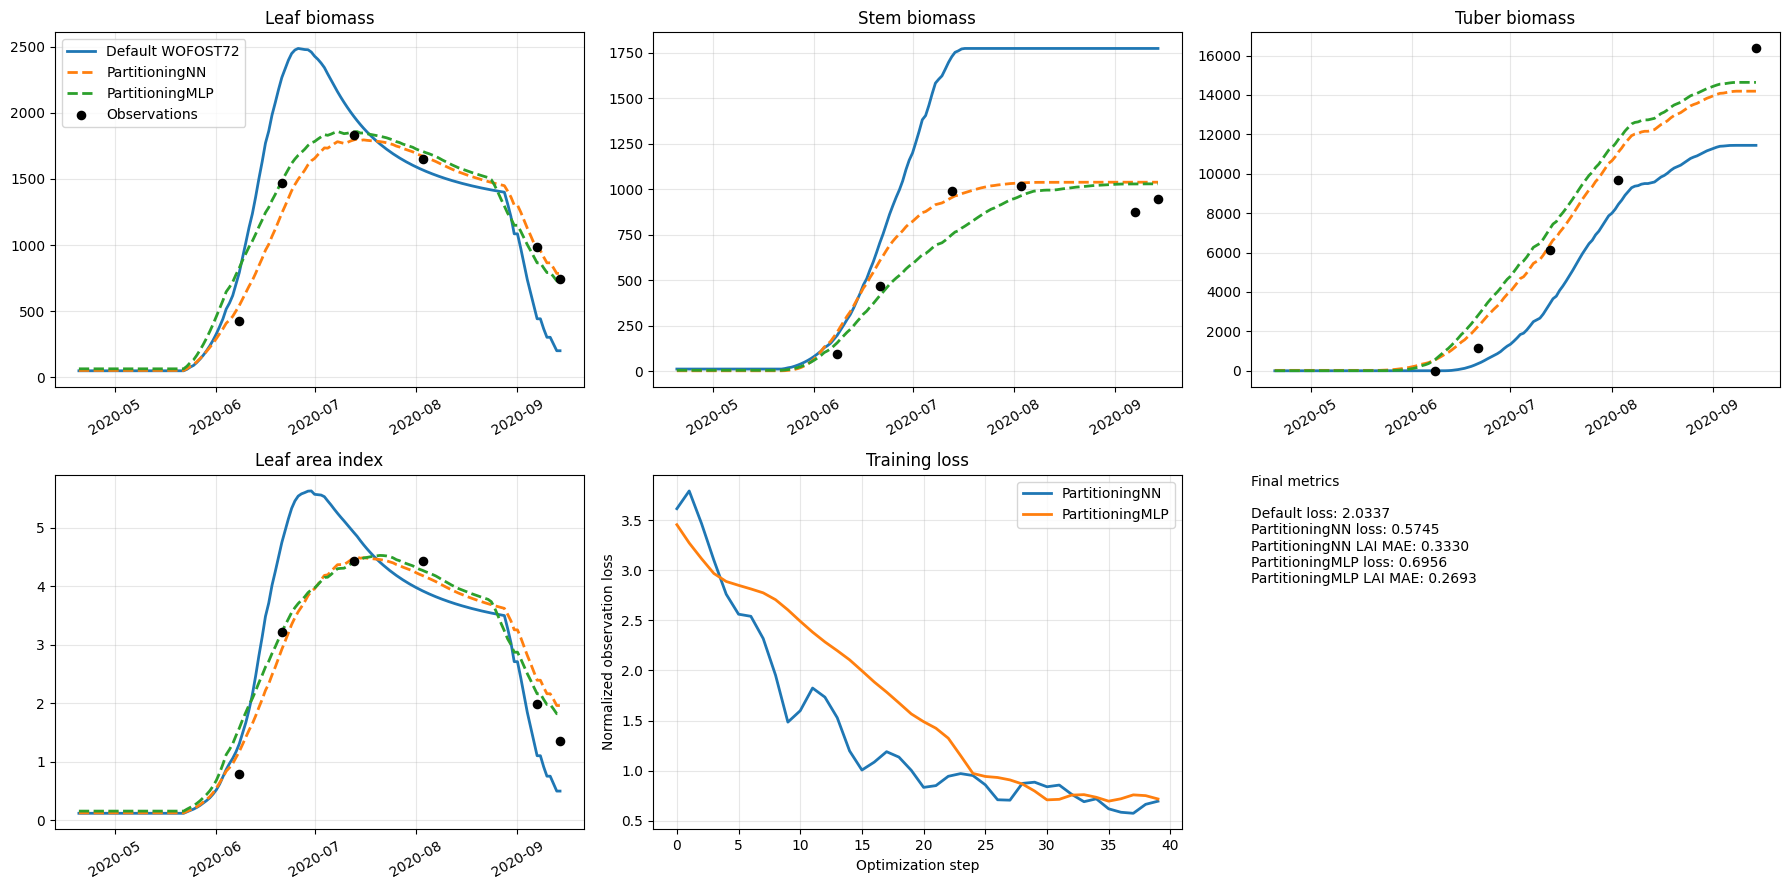

In [13]:
reference_frame = tensors_to_frame(reference_results)
trained_frames = {
    model_name: tensors_to_frame(run_info["results"])
    for model_name, run_info in training_runs.items()
}

fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=False)
panels = [
    ("WLV", "WLV", "Leaf biomass"),
    ("TWST", "TWST", "Stem biomass"),
    ("TWSO", "TWSO", "Tuber biomass"),
    ("LAI", "LAI", "Leaf area index"),
]

for ax, (obs_name, sim_name, title) in zip(axes.ravel()[:4], panels, strict=False):
    ax.plot(reference_frame.index, reference_frame[sim_name], label="Default WOFOST72", linewidth=2)
    for fitted_name, frame in trained_frames.items():
        ax.plot(
            frame.index,
            frame[sim_name],
            label=fitted_name,
            linewidth=2,
            linestyle="--",
        )
    ax.scatter(
        matched_observations.index,
        matched_observations[obs_name],
        color="black",
        s=35,
        label="Observations",
        zorder=5,
    )
    ax.set_title(title)
    ax.grid(alpha=0.3)

axes[0, 0].legend(loc="upper left")

loss_ax = axes[1, 1]
for model_name, run_info in training_runs.items():
    loss_ax.plot(run_info["loss_history"], linewidth=2, label=model_name)
loss_ax.set_title("Training loss")
loss_ax.set_xlabel("Optimization step")
loss_ax.set_ylabel("Normalized observation loss")
loss_ax.grid(alpha=0.3)
loss_ax.legend()

summary_ax = axes[1, 2]
summary_ax.axis("off")
summary_lines = [
    "Final metrics",
    "",
    f"Default loss: {reference_loss.detach().item():.4f}",
]
for model_name, run_info in training_runs.items():
    summary_lines.append(f"{model_name} loss: {run_info['final_total_loss']:.4f}")
    summary_lines.append(f"{model_name} LAI MAE: {run_info['final_lai_mae']:.4f}")
summary_ax.text(0.0, 1.0, "\n".join(summary_lines), va="top")

for ax in axes.ravel()[:4]:
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


### 6.1 Inspect the learned partitioning curves

The next plot compares the learned partitioning fractions with the default WOFOST72 partitioning module on the Fontane 2020 run.

This is the main internal diagnostic after a module replacement: even when the external outputs fit the observations, the replacement module may represent the internal process differently.

Remember that these curves are not direct training targets.

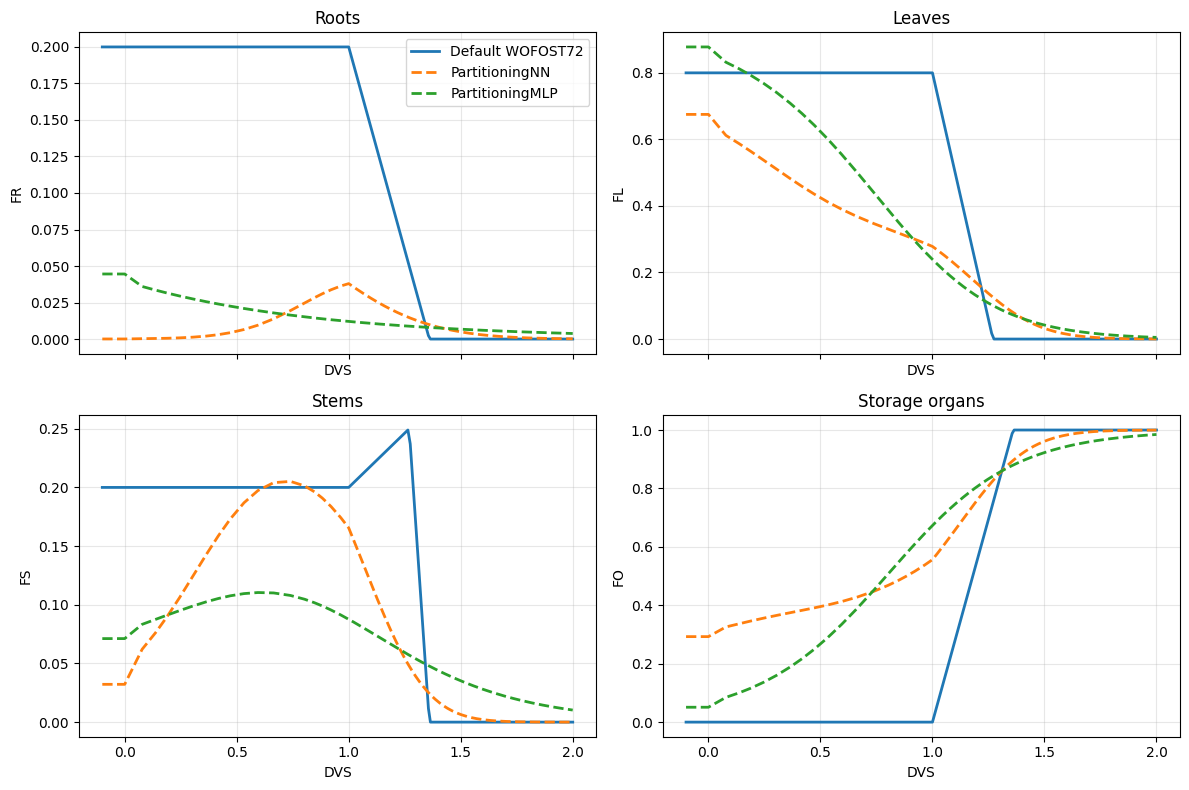

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
curves = [
    ("FR", "Roots"),
    ("FL", "Leaves"),
    ("FS", "Stems"),
    ("FO", "Storage organs"),
]

for ax, (varname, title) in zip(axes.ravel(), curves, strict=False):
    ax.plot(
        reference_results["DVS"].detach().cpu().numpy(),
        reference_results[varname].detach().cpu().numpy(),
        label="Default WOFOST72",
        linewidth=2,
    )

    for model_name, run_info in training_runs.items():
        ax.plot(
            run_info["results"]["DVS"].detach().cpu().numpy(),
            run_info["results"][varname].detach().cpu().numpy(),
            label=model_name,
            linewidth=2,
            linestyle="--",
        )

    ax.set_title(title)
    ax.set_xlabel("DVS")
    ax.set_ylabel(varname)
    ax.grid(alpha=0.3)

axes[0, 0].legend()
plt.tight_layout()
plt.show()

This comparison makes the main modeling point visible: matching the observed biomass and LAI series does not uniquely determine the internal partitioning trajectory.

In practice, <code>PartitioningNN</code> and <code>PartitioningMLP</code> can fit the same field measurements while implying different <code>FR</code>, <code>FL</code>, <code>FS</code>, and <code>FO</code> curves. 